In [ ]:
!pip install transformers
!pip install torch
!pip install sentence-transformers
!pip install nltk
!pip install googletrans==4.0.0-rc1
!pip install scipy

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [ ]:
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
from sklearn.metrics.pairwise import cosine_similarity
from googletrans import Translator
from transformers import BertModel, BertTokenizer
import torch
import nltk
from nltk.corpus import stopwords
import re
from sklearn.preprocessing import normalize
from scipy.special import rel_entr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
resume_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Test_git/PPA-main/extracted_cvs.csv', on_bad_lines='skip')
jobs_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Test_git/PPA-main/VDAB_data_translated_provinces.csv') #de url links werken, maar je moet ze volledig kopieren

In [ ]:
resume_df

,file_path,content
0,./CV Mikail.pdf,CURRICULUM VITAE\n\nMIKAIL MALCIKAN\n\nL I N K...
1,Ayush_Shrestha_CV.pdf,AYUSH SHRESTHA\n\nS t u d e n t\n\nABOUT ME\n\...
2,Cv_George_Lemmens.pdf,George Lemmens\n\nErvaring\n\n2020 - 2021\n\nM...
3,CV Mikail.pdf,CURRICULUM VITAE\n\nMIKAIL MALCIKAN\n\nL I N K...
4,Ayush_Shrestha_CV.pdf,AYUSH SHRESTHA\n\nS t u d e n t\n\nABOUT ME\n\...
5,Ayush_Shrestha_CV.pdf,AYUSH SHRESTHA\n\nS t u d e n t\n\nABOUT ME\n\...


In [ ]:
jobs_df.head()

,url,title,employer,location,description,description_translated,title_translated,province
0,https://www.vdab.be/vindeenjob/vacatures/68793122,technisch aankoopassistent,le grand & associates,kortrijk,Functieomschrijving LGA Engineering is een rek...,Job description LGA Engineering is a recruitme...,technical purchasing assistant,West Flanders
1,https://www.vdab.be/vindeenjob/vacatures/68793123,pricing analist,lga engineering,provincie vlaams-brabant,Functieomschrijving Heb jij een passie voor de...,Job description Do you have a passion for the ...,pricing analist,Flemish Brabant
2,https://www.vdab.be/vindeenjob/vacatures/68793124,pricing analist maritiem,lga engineering,antwerpen,Functieomschrijving Voor onze logistieke klant...,Job description For our logistics customer in ...,maritime pricing analyst,Antwerp
3,https://www.vdab.be/vindeenjob/vacatures/68793125,warehouse teamleader,start people,herentals,Functieomschrijving Onze klant gevestigd in He...,Job description Our client based in Herentals ...,warehouse team leader,Antwerp
4,https://www.vdab.be/vindeenjob/vacatures/68793126,grafisch vormgever,start people,pelt,Functieomschrijving 1 op de 10 gezinnen geniet...,Job description 1 in 10 families already enjoy...,graphical designer,Limburg


In [ ]:
jobs_df.dropna(inplace=True)

In [ ]:
# Define the comprehensive cleaning function
def cleaning(text):
    if not isinstance(text, str):
        return ""
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Remove URLs
    text = re.sub(r"https?://\S+", "", text)

    # Remove hashtags
    text = re.sub(r"#\w+", "", text)

    # Remove non-ASCII characters
    text = re.sub(r"[^\x00-\x7F]+", "", text)

    # Remove newline characters
    text = re.sub(r"\n", " ", text)

    # Remove leading/trailing spaces
    text = re.sub(r"^\s+", "", text)
    text = re.sub(r"\s+$", "", text)

    # Remove multiple spaces
    text = re.sub(r"[ |\t]+", " ", text)

    # Remove parentheses and slashes
    text = re.sub(r"[()]", "", text)
    text = re.sub(r"/", " ", text)

    # Remove commas and periods
    text = re.sub(r",", " ", text)
    text = re.sub(r"\. ", " ", text)

    # Remove colons and semicolons
    text = re.sub(r":", " ", text)
    text = re.sub(r";", " ", text)

    # Remove numbers
    text = re.sub(r"\b\d+\b", "", text)

    # Remove carriage returns
    text = re.sub(r"\r", "", text)

    # Remove quotes and ampersands
    text = re.sub(r"\"", "", text)
    text = re.sub(r"&", "", text)

    # Remove hyphens, plus signs, asterisks, and equal signs
    text = re.sub(r"-", "", text)
    text = re.sub(r"\+", "", text)
    text = re.sub(r"\*", "", text)
    text = re.sub(r"\.", "", text)
    text = re.sub(r"=", "", text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters (if any left)
    text = re.sub(r"[^\w\s]", "", text)

    # Remove multiple spaces again just in case
    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
def cleaning(text):
    text = re.sub("@\\w+", "", text)
    text = re.sub("https?://.+", "", text)
    text = re.sub("#\\w+", "", text)
    text = re.sub("[^\x01-\x7F]", "", text)
    text = re.sub("\n", " ", text)
    text = re.sub("^\\s+", "", text)
    text = re.sub("\\s+$", "", text)
    text = re.sub("[ |\t]+", " ", text)
    text = re.sub("\\(", "", text)
    text = re.sub("\\)", "", text)
    text = re.sub("/", " ", text)
    text = re.sub(",", " ", text)
    text = re.sub("\\. ", " ", text)
    text = re.sub("\\:", " ", text)
    text = re.sub("\\;", " ", text)
    text = re.sub("\\b\\d+\\b", "", text)
    text = re.sub("\r", "", text)
    text = re.sub("\"", "", text)
    text = re.sub("&", "", text)
    text = re.sub("-", "", text)
    text = re.sub("\+", "", text)
    text = re.sub("\*", "", text)
    text = re.sub("\.", "", text)
    text = re.sub("=", "", text)
    text = text.lower()
    return(text)

In [ ]:
# Clean and translate the 'content' column
resume_df['clean_content'] = resume_df['content'].apply(lambda x: cleaning(x))

# Clean and translate the 'Job Description' column
jobs_df['clean_description'] = jobs_df['description_translated'].apply(lambda x: cleaning(str(x)))
#jobs_df['clean_address'] = jobs_df['Address'].apply(lambda x: cleaning(str(x)))


In [ ]:
jobs_df.head()

,url,title,employer,location,description,description_translated,title_translated,province,clean_description
0,https://www.vdab.be/vindeenjob/vacatures/68793122,technisch aankoopassistent,le grand & associates,kortrijk,Functieomschrijving LGA Engineering is een rek...,Job description LGA Engineering is a recruitme...,technical purchasing assistant,West Flanders,job description lga engineering is a recruitme...
1,https://www.vdab.be/vindeenjob/vacatures/68793123,pricing analist,lga engineering,provincie vlaams-brabant,Functieomschrijving Heb jij een passie voor de...,Job description Do you have a passion for the ...,pricing analist,Flemish Brabant,job description do you have a passion for the ...
2,https://www.vdab.be/vindeenjob/vacatures/68793124,pricing analist maritiem,lga engineering,antwerpen,Functieomschrijving Voor onze logistieke klant...,Job description For our logistics customer in ...,maritime pricing analyst,Antwerp,job description for our logistics customer in ...
3,https://www.vdab.be/vindeenjob/vacatures/68793125,warehouse teamleader,start people,herentals,Functieomschrijving Onze klant gevestigd in He...,Job description Our client based in Herentals ...,warehouse team leader,Antwerp,job description our client based in herentals ...
4,https://www.vdab.be/vindeenjob/vacatures/68793126,grafisch vormgever,start people,pelt,Functieomschrijving 1 op de 10 gezinnen geniet...,Job description 1 in 10 families already enjoy...,graphical designer,Limburg,job description in families already enjoy our ...


In [ ]:
resume_df.head()

,file_path,content,clean_content
0,./CV Mikail.pdf,CURRICULUM VITAE\n\nMIKAIL MALCIKAN\n\nL I N K...,curriculum vitae mikail malcikan l i n k e d i...
1,Ayush_Shrestha_CV.pdf,AYUSH SHRESTHA\n\nS t u d e n t\n\nABOUT ME\n\...,ayush shrestha s t u d e n t about me ayush121...
2,Cv_George_Lemmens.pdf,George Lemmens\n\nErvaring\n\n2020 - 2021\n\nM...,george lemmens ervaring mowi en bakkerij notre...
3,CV Mikail.pdf,CURRICULUM VITAE\n\nMIKAIL MALCIKAN\n\nL I N K...,curriculum vitae mikail malcikan l i n k e d i...
4,Ayush_Shrestha_CV.pdf,AYUSH SHRESTHA\n\nS t u d e n t\n\nABOUT ME\n\...,ayush shrestha s t u d e n t about me ayush121...


In [ ]:
jobs_df.to_csv('jobs_df.csv', index_label=False)

In [ ]:
resume_df.to_csv('resume_df.csv', index_label=False)

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial.distance import jensenshannon
import numpy as np


# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Create a vectorizer to convert text data into term-frequency vectors
vectorizer = CountVectorizer()

# Vectorize the clean_description and clean_content columns
job_desc_matrix = vectorizer.fit_transform(jobs_df['clean_description'])
resume_content_matrix = vectorizer.transform(resume_df['clean_content'])

# Convert to numpy arrays
job_desc_array = job_desc_matrix.toarray()
resume_content_array = resume_content_matrix.toarray()

# Normalize the term-frequency vectors to probabilities
job_desc_prob = job_desc_array / job_desc_array.sum(axis=1, keepdims=True)
resume_content_prob = resume_content_array / resume_content_array.sum(axis=1, keepdims=True)

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Calculate KL divergence for each pair of job description and resume content
kl_divergences = []
top_words = []

for job_prob in job_desc_prob:
    job_top_words = []
    for resume_prob in resume_content_prob:
        # Jensen-Shannon divergence is a symmetric and finite version of KL divergence
        js_divergence = jensenshannon(job_prob, resume_prob) ** 2
        kl_divergences.append(js_divergence)

        # Calculate divergence contribution per word
        m = 0.5 * (job_prob + resume_prob)
        kl_job = job_prob * np.log(job_prob / m)
        kl_resume = resume_prob * np.log(resume_prob / m)
        kl_contrib = 0.5 * (kl_job + kl_resume)

        # Get top 10 words contributing to the divergence
        top_word_indices = np.argsort(kl_contrib)[-10:]
        top_word_contributions = [(feature_names[i], kl_contrib[i]) for i in top_word_indices]
        job_top_words.append(top_word_contributions)

    top_words.append(job_top_words)

kl_divergences = np.array(kl_divergences).reshape(len(jobs_df), len(resume_df))

# Display the KL divergence matrix
kl_divergence_df = pd.DataFrame(kl_divergences)
print(kl_divergence_df)

# Display the top 10 words contributing to the divergence for the first job-resume pair
print("Top 10 words contributing to divergence for the first job-resume pair:")
print(top_words[0][0])


<ipython-input-23-7a821ac6d3b5>:42: RuntimeWarning: invalid value encountered in divide
  kl_job = job_prob * np.log(job_prob / m)
<ipython-input-23-7a821ac6d3b5>:42: RuntimeWarning: divide by zero encountered in log
  kl_job = job_prob * np.log(job_prob / m)
<ipython-input-23-7a821ac6d3b5>:42: RuntimeWarning: invalid value encountered in multiply
  kl_job = job_prob * np.log(job_prob / m)
<ipython-input-23-7a821ac6d3b5>:43: RuntimeWarning: invalid value encountered in divide
  kl_resume = resume_prob * np.log(resume_prob / m)
<ipython-input-23-7a821ac6d3b5>:43: RuntimeWarning: divide by zero encountered in log
  kl_resume = resume_prob * np.log(resume_prob / m)
<ipython-input-23-7a821ac6d3b5>:43: RuntimeWarning: invalid value encountered in multiply
  kl_resume = resume_prob * np.log(resume_prob / m)


           0         1         2         3         4         5
0   0.472959  0.426313  0.682246  0.472959  0.426313  0.426313
1   0.435101  0.401342  0.678425  0.435101  0.401342  0.401342
2   0.524358  0.499555  0.680395  0.524358  0.499555  0.499555
3   0.465711  0.430975  0.684592  0.465711  0.430975  0.430975
4   0.476081  0.435658  0.682499  0.476081  0.435658  0.435658
5   0.496591  0.475366  0.678763  0.496591  0.475366  0.475366
6   0.521524  0.487730  0.689855  0.521524  0.487730  0.487730
7   0.454382  0.425953  0.682458  0.454382  0.425953  0.425953
8   0.499005  0.437737  0.693147  0.499005  0.437737  0.437737
9   0.485520  0.468109  0.672306  0.485520  0.468109  0.468109
10  0.491119  0.459208  0.684778  0.491119  0.459208  0.459208
11  0.469371  0.456244  0.676637  0.469371  0.456244  0.456244
12  0.495773  0.462594  0.679693  0.495773  0.462594  0.462594
13  0.458313  0.432475  0.681439  0.458313  0.432475  0.432475
14  0.470832  0.446781  0.668647  0.470832  0.446781  0

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial.distance import jensenshannon
import numpy as np


# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Create a vectorizer to convert text data into term-frequency vectors
vectorizer = CountVectorizer()

# Vectorize the clean_description and clean_content columns
job_desc_matrix = vectorizer.fit_transform(jobs_df['clean_description'])
resume_content_matrix = vectorizer.transform(resume_df['clean_content'])

# Convert to numpy arrays
job_desc_array = job_desc_matrix.toarray()
resume_content_array = resume_content_matrix.toarray()

# Normalize the term-frequency vectors to probabilities
job_desc_prob = job_desc_array / job_desc_array.sum(axis=1, keepdims=True)
resume_content_prob = resume_content_array / resume_content_array.sum(axis=1, keepdims=True)

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Calculate KL divergence for each pair of job description and resume content
kl_divergences = []
top_words = []

for job_prob in job_desc_prob:
    job_top_words = []
    for resume_prob in resume_content_prob:
        # Jensen-Shannon divergence is a symmetric and finite version of KL divergence
        js_divergence = jensenshannon(job_prob, resume_prob) ** 2
        kl_divergences.append(js_divergence)

        # Calculate divergence contribution per word
        m = 0.5 * (job_prob + resume_prob)
        kl_job = job_prob * np.log(job_prob / m)
        kl_resume = resume_prob * np.log(resume_prob / m)
        kl_contrib = 0.5 * (kl_job + kl_resume)

        # Get top 10 words contributing to the divergence
        top_word_indices = np.argsort(kl_contrib)[-10:]
        top_word_contributions = [(feature_names[i], kl_contrib[i]) for i in top_word_indices]
        job_top_words.append(top_word_contributions)

    top_words.append(job_top_words)

kl_divergences = np.array(kl_divergences).reshape(len(jobs_df), len(resume_df))

# Display the KL divergence matrix
kl_divergence_df = pd.DataFrame(kl_divergences)
print(kl_divergence_df)

# Identify the pair with the highest divergence
max_divergence_index = np.unravel_index(np.argmax(kl_divergences), kl_divergences.shape)
max_divergence_words = top_words[max_divergence_index[0]][max_divergence_index[1]]

# Identify the pair with the lowest divergence
min_divergence_index = np.unravel_index(np.argmin(kl_divergences), kl_divergences.shape)
min_divergence_words = top_words[min_divergence_index[0]][min_divergence_index[1]]

# Display the top 10 words contributing to the highest divergence
print("\nTop 10 words contributing to the highest divergence:")
print(max_divergence_words)

# Display the top 10 words contributing to the lowest divergence
print("\nTop 10 words contributing to the lowest divergence:")
print(min_divergence_words)


<ipython-input-24-e9b2b43b8b5a>:42: RuntimeWarning: invalid value encountered in divide
  kl_job = job_prob * np.log(job_prob / m)
<ipython-input-24-e9b2b43b8b5a>:42: RuntimeWarning: divide by zero encountered in log
  kl_job = job_prob * np.log(job_prob / m)
<ipython-input-24-e9b2b43b8b5a>:42: RuntimeWarning: invalid value encountered in multiply
  kl_job = job_prob * np.log(job_prob / m)
<ipython-input-24-e9b2b43b8b5a>:43: RuntimeWarning: invalid value encountered in divide
  kl_resume = resume_prob * np.log(resume_prob / m)
<ipython-input-24-e9b2b43b8b5a>:43: RuntimeWarning: divide by zero encountered in log
  kl_resume = resume_prob * np.log(resume_prob / m)
<ipython-input-24-e9b2b43b8b5a>:43: RuntimeWarning: invalid value encountered in multiply
  kl_resume = resume_prob * np.log(resume_prob / m)


           0         1         2         3         4         5
0   0.472959  0.426313  0.682246  0.472959  0.426313  0.426313
1   0.435101  0.401342  0.678425  0.435101  0.401342  0.401342
2   0.524358  0.499555  0.680395  0.524358  0.499555  0.499555
3   0.465711  0.430975  0.684592  0.465711  0.430975  0.430975
4   0.476081  0.435658  0.682499  0.476081  0.435658  0.435658
5   0.496591  0.475366  0.678763  0.496591  0.475366  0.475366
6   0.521524  0.487730  0.689855  0.521524  0.487730  0.487730
7   0.454382  0.425953  0.682458  0.454382  0.425953  0.425953
8   0.499005  0.437737  0.693147  0.499005  0.437737  0.437737
9   0.485520  0.468109  0.672306  0.485520  0.468109  0.468109
10  0.491119  0.459208  0.684778  0.491119  0.459208  0.459208
11  0.469371  0.456244  0.676637  0.469371  0.456244  0.456244
12  0.495773  0.462594  0.679693  0.495773  0.462594  0.462594
13  0.458313  0.432475  0.681439  0.458313  0.432475  0.432475
14  0.470832  0.446781  0.668647  0.470832  0.446781  0

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
from googletrans import Translator

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Function to translate text from Dutch to English
translator = Translator()

def translate_text(text):
    try:
        translation = translator.translate(text, src='nl', dest='en')
        return translation.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text

# Translate the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(lambda x: translate_text(x) if pd.notnull(x) else "")
resume_df['clean_content'] = resume_df['clean_content'].apply(lambda x: translate_text(x) if pd.notnull(x) else "")

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Create a vectorizer to convert text data into term-frequency vectors
vectorizer = CountVectorizer()

# Vectorize the clean_description and clean_content columns
job_desc_matrix = vectorizer.fit_transform(jobs_df['clean_description'])
resume_content_matrix = vectorizer.transform(resume_df['clean_content'])

# Calculate cosine similarity
cosine_similarities = cosine_similarity(job_desc_matrix, resume_content_matrix)

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Calculate the top contributing words for highest and lowest similarity pairs
top_words_high_sim = []
top_words_low_sim = []

for job_idx, job_vector in enumerate(job_desc_matrix.toarray()):
    for resume_idx, resume_vector in enumerate(resume_content_matrix.toarray()):
        # Contribution of words for the similarity
        word_contributions = job_vector * resume_vector

        # Get top 10 words contributing to similarity
        top_word_indices = np.argsort(word_contributions)[-10:]
        top_words = [feature_names[i] for i in top_word_indices]

        if cosine_similarities[job_idx, resume_idx] == cosine_similarities.max():
            top_words_high_sim = top_words
        elif cosine_similarities[job_idx, resume_idx] == cosine_similarities.min():
            top_words_low_sim = top_words

# Display the cosine similarity matrix
cosine_similarity_df = pd.DataFrame(cosine_similarities)
print(cosine_similarity_df)

# Display the top 10 words contributing to the highest similarity
print("\nTop 10 words contributing to the highest similarity:")
print(top_words_high_sim)

# Display the top 10 words contributing to the lowest similarity:
print("\nTop 10 words contributing to the lowest similarity:")
print(top_words_low_sim)


Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
           0         1         2         3         4         5
0   0.237354  0.261786  0.045466  0.237354  0.261786  0.261786
1   0.168785  0.304256  0.028868  0.168785  0.304256  0.304256
2   0.056442  0.087048  0.000000  0.056442  0.087048  0.087048
3   0.231571  0.269594  0.029704  0.231571  0.269594  0.269594
4   0.226956  0.294227  0.022333  0.226956  0.294227  0.294227
5   0.092563  0.101968  0.000000  0.092563  0.101968  0.101968
6   0.037719  0.047008  0.000000  0.037719  0.047008  0.047008
7   0.2196

Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
           0         1         2         3         4         5
0   0.156778  0.103952  0.023204  0.156778  0.103952  0.103952
1   0.085563  0.047571  0.000000  0.085563  0.047571  0.047571
2   0.018564  0.013379  0.000000  0.018564  0.013379  0.013379
3   0.239599  0.151495  0.004470  0.239599  0.151495  0.151495
4   0.164284  0.131152  0.070138  0.164284  0.131152  0.131152
5   0.029391  0.063546  0.086998  0.029391  0.063546  0.063546
6   0.007437  0.028945  0.033023  0.007437  0.028945  0.028945
7   0.1112

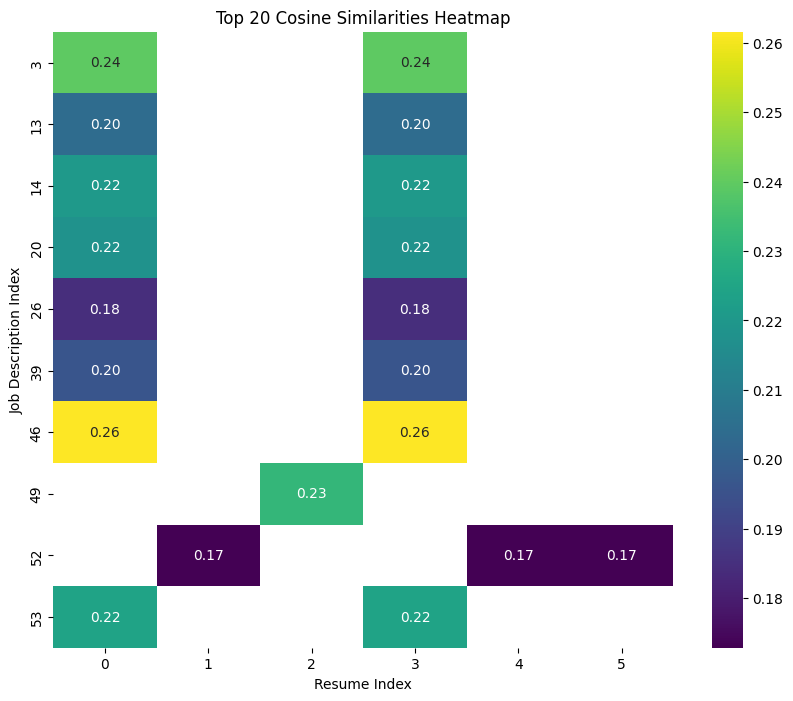

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
from googletrans import Translator
import seaborn as sns
import matplotlib.pyplot as plt


# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Function to translate text from Dutch to English
translator = Translator()

def translate_text(text):
    try:
        translation = translator.translate(text, src='nl', dest='en')
        return translation.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text

# Translate the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(lambda x: translate_text(x) if pd.notnull(x) else "")
resume_df['clean_content'] = resume_df['clean_content'].apply(lambda x: translate_text(x) if pd.notnull(x) else "")

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Create a vectorizer to convert text data into term-frequency vectors
vectorizer = CountVectorizer()

# Vectorize the clean_description and clean_content columns
job_desc_matrix = vectorizer.fit_transform(jobs_df['clean_description'])
resume_content_matrix = vectorizer.transform(resume_df['clean_content'])

# Calculate cosine similarity
cosine_similarities = cosine_similarity(job_desc_matrix, resume_content_matrix)

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Calculate the top contributing words for highest and lowest similarity pairs
top_words_high_sim = []
top_words_low_sim = []

for job_idx, job_vector in enumerate(job_desc_matrix.toarray()):
    for resume_idx, resume_vector in enumerate(resume_content_matrix.toarray()):
        # Contribution of words for the similarity
        word_contributions = job_vector * resume_vector

        # Get top 10 words contributing to similarity
        top_word_indices = np.argsort(word_contributions)[-10:]
        top_words = [feature_names[i] for i in top_word_indices]

        if cosine_similarities[job_idx, resume_idx] == cosine_similarities.max():
            top_words_high_sim = top_words
        elif cosine_similarities[job_idx, resume_idx] == cosine_similarities.min():
            top_words_low_sim = top_words

# Display the cosine similarity matrix
cosine_similarity_df = pd.DataFrame(cosine_similarities)
print(cosine_similarity_df)

# Display the top 10 words contributing to the highest similarity
print("\nTop 10 words contributing to the highest similarity:")
print(top_words_high_sim)

# Display the top 10 words contributing to the lowest similarity:
print("\nTop 10 words contributing to the lowest similarity:")
print(top_words_low_sim)

# Extract top 20 similarities
top_20_similarities_indices = np.dstack(np.unravel_index(np.argsort(cosine_similarities.ravel())[-20:], cosine_similarities.shape))[0]

# Create a DataFrame for the top 20 similarities
top_20_similarities = pd.DataFrame({
    'Job Index': top_20_similarities_indices[:, 0],
    'Resume Index': top_20_similarities_indices[:, 1],
    'Similarity': cosine_similarities[top_20_similarities_indices[:, 0], top_20_similarities_indices[:, 1]]
})

# Generate a heatmap for the top 20 similarities
plt.figure(figsize=(10, 8))
heatmap_data = pd.pivot_table(top_20_similarities, values='Similarity', index='Job Index', columns='Resume Index')
sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='.2f')
plt.title('Top 20 Cosine Similarities Heatmap')
plt.xlabel('Resume Index')
plt.ylabel('Job Description Index')
plt.show()


In [ ]:
# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to translate text from Dutch to English
translator = Translator()

def translate_text(text):
    if text is None or text.strip() == "":
        return ""
    try:
        translation = translator.translate(text, src='nl', dest='en')
        return translation.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text

# Translate the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(translate_text)
resume_df['clean_content'] = resume_df['clean_content'].apply(translate_text)

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Function to get BERT embeddings
def get_bert_embeddings(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)
    embeddings = model_output.last_hidden_state.mean(dim=1).numpy()
    return embeddings

# Generate embeddings for job descriptions and resume content
job_embeddings = get_bert_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_bert_embeddings(resume_df['clean_content'].tolist())

# Calculate cosine similarity
cosine_similarities = cosine_similarity(job_embeddings, resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top matching job descriptions for each resume
top_matches = cosine_similarity_df.idxmax(axis=0)

# Display the top matches
for resume_idx, job_idx in top_matches.items():
    print(f"Resume {resume_idx} matches best with Job {job_idx} with a similarity score of {cosine_similarity_df.loc[job_idx, resume_idx]:.4f}")


Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

           0         1         2         3         4         5
0   0.713070  0.901279  0.562342  0.713070  0.901279  0.901279
1   0.831998  0.923729  0.694426  0.831998  0.923729  0.923729
2   0.912674  0.792536  0.789855  0.912674  0.792536  0.792536
3   0.705081  0.892782  0.558178  0.705081  0.892782  0.892782
4   0.794844  0.927458  0.669987  0.794844  0.927458  0.927458
5   0.715498  0.900585  0.589151  0.715498  0.900585  0.900585
6   0.742486  0.895776  0.618228  0.742486  0.895776  0.895776
7   0.781568  0.911650  0.639774  0.781568  0.911650  0.911650
8   0.644948  0.905291  0.489482  0.644948  0.905291  0.905291
9   0.832956  0.912706  0.699818  0.832956  0.912706  0.912706
10  0.660710  0.846606  0.531323  0.660710  0.846606  0.846606
11  0.748358  0.924232  0.594636  0.748358  0.924232  0.924232
12  0.675730  0.850978  0.537888  0.675730  0.850978  0.850978
13  0.712409  0.892568  0.595984  0.712409  0.892568  0.892568
14  0.831484  0.870048  0.688988  0.831484  0.870048  0

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from googletrans import Translator
from transformers import BertModel, BertTokenizer
import torch

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to translate text from Dutch to English
translator = Translator()

def translate_text(text):
    if text is None or text.strip() == "":
        return ""
    try:
        translation = translator.translate(text, src='nl', dest='en')
        return translation.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text

# Translate the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(translate_text)
resume_df['clean_content'] = resume_df['clean_content'].apply(translate_text)

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-large-cased-whole-word-masking')
model = BertModel.from_pretrained('bert-large-cased-whole-word-masking')

# Function to get BERT embeddings
def get_bert_embeddings(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)
    embeddings = model_output.last_hidden_state.mean(dim=1).numpy()
    return embeddings

# Generate embeddings for job descriptions and resume content
job_embeddings = get_bert_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_bert_embeddings(resume_df['clean_content'].tolist())

# Calculate cosine similarity
cosine_similarities = cosine_similarity(job_embeddings, resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top matching job descriptions for each resume
top_matches = cosine_similarity_df.idxmax(axis=0)

# Display the top matches with job titles
for resume_idx, job_idx in top_matches.items():
    job_title = jobs_df.loc[job_idx, 'title_translated']
    similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
    print(f"Resume {resume_idx} matches best with Job '{job_title}' with a similarity score of {similarity_score:.4f}")


Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType
Translation error: the JSON object must be str, bytes or bytearray, not NoneType


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

           0         1         2         3         4         5
0   0.897865  0.890982  0.872132  0.897865  0.890982  0.890982
1   0.966571  0.959606  0.929017  0.966571  0.959606  0.959606
2   0.739650  0.832593  0.688219  0.739650  0.832593  0.832593
3   0.915119  0.934060  0.873726  0.915119  0.934060  0.934060
4   0.918233  0.956354  0.880550  0.918233  0.956354  0.956354
5   0.931259  0.962004  0.893161  0.931259  0.962004  0.962004
6   0.918311  0.951117  0.877131  0.918311  0.951117  0.951117
7   0.929816  0.941062  0.887203  0.929816  0.941062  0.941062
8   0.810444  0.864244  0.774583  0.810444  0.864244  0.864244
9   0.916595  0.947067  0.878268  0.916595  0.947067  0.947067
10  0.892986  0.917813  0.852602  0.892986  0.917813  0.917813
11  0.927124  0.958935  0.885560  0.927124  0.958935  0.958935
12  0.871778  0.887898  0.851559  0.871778  0.887898  0.887898
13  0.893488  0.916428  0.848681  0.893488  0.916428  0.916428
14  0.940221  0.958516  0.904597  0.940221  0.958516  0

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from googletrans import Translator
from transformers import BertModel, BertTokenizer
import torch
import nltk
from nltk.corpus import stopwords
import re

# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to translate text from Dutch to English
#translator = Translator()

# def translate_text(text):
#     if text is None or text.strip() == "":
#         return ""
#     try:
#         translation = translator.translate(text, src='nl', dest='en')
#         return translation.text
#     except Exception as e:
#         print(f"Translation error: {e}")
#         return text

# # Translate the descriptions and content
# jobs_df['clean_description'] = jobs_df['clean_description'].apply(translate_text)
# resume_df['clean_content'] = resume_df['clean_content'].apply(translate_text)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-large-cased-whole-word-masking')
model = BertModel.from_pretrained('bert-large-cased-whole-word-masking')

# Function to get BERT embeddings
def get_bert_embeddings(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)
    embeddings = model_output.last_hidden_state.mean(dim=1).numpy()
    return embeddings

# Generate embeddings for job descriptions and resume content
job_embeddings = get_bert_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_bert_embeddings(resume_df['clean_content'].tolist())

# Calculate cosine similarity
cosine_similarities = cosine_similarity(job_embeddings, resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import numpy as np
from googletrans import Translator
import nltk
from nltk.corpus import stopwords
import re

# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# # Function to translate text from Dutch to English
# # translator = Translator()

# def translate_text(text):
#     if text is None or text.strip() == "":
#         return ""
#     try:
#         translation = translator.translate(text, src='nl', dest='en')
#         return translation.text
#     except Exception as e:
#         print(f"Translation error: {e}")
#         return text

# # Translate the descriptions and content
# jobs_df['clean_description'] = jobs_df['clean_description'].apply(translate_text)
# resume_df['clean_content'] = resume_df['clean_content'].apply(translate_text)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Load pre-trained SBERT model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Function to get SBERT embeddings
def get_sbert_embeddings(texts):
    return model.encode(texts, convert_to_tensor=True)

# Generate embeddings for job descriptions and resume content
job_embeddings = get_sbert_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_sbert_embeddings(resume_df['clean_content'].tolist())

# Calculate cosine similarity
cosine_similarities = util.pytorch_cos_sim(job_embeddings, resume_embeddings).cpu().numpy()

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


              0         1         2         3         4         5
0      0.597004  0.498552  0.305178  0.597004  0.498552  0.498552
1      0.559700  0.486243  0.250231  0.559700  0.486243  0.486243
2      0.603547  0.456617  0.254852  0.603547  0.456617  0.456617
3      0.582855  0.498095  0.332574  0.582855  0.498095  0.498095
4      0.451579  0.472353  0.377649  0.451579  0.472353  0.472353
...         ...       ...       ...       ...       ...       ...
11122  0.514531  0.387441  0.303625  0.514531  0.387441  0.387441
11123  0.530695  0.455159  0.250823  0.530695  0.455159  0.455159
11124  0.562068  0.455066  0.200436  0.562068  0.455066  0.455066
11125  0.499432  0.397923  0.239085  0.499432  0.397923  0.397923
11126  0.503177  0.466739  0.341383  0.503177  0.466739  0.466739

[11127 rows x 6 columns]
Resume 0 top 5 matches:
  Job 'bi developer in wommelgem' with a similarity score of 0.7698
  Job 'business intelligence developer' with a similarity score of 0.7374
  Job 'junior so

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
import re
import numpy as np

# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Function to extract education section (simple heuristic)
def extract_education(text):
    education_keywords = ['education', 'degree', 'university', 'bachelor', 'master', 'phd']
    sentences = text.split('.')
    education_sentences = [sentence for sentence in sentences if any(keyword in sentence.lower() for keyword in education_keywords)]
    return ' '.join(education_sentences)

# Extract education sections
jobs_df['education_section'] = jobs_df['clean_description'].apply(extract_education)
resume_df['education_section'] = resume_df['clean_content'].apply(extract_education)

# Load pre-trained Sentence-BERT model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Function to get embeddings
def get_embeddings(texts):
    return model.encode(texts, batch_size=16, show_progress_bar=True)

# Generate embeddings for job descriptions, resumes, and education sections
job_embeddings = get_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_embeddings(resume_df['clean_content'].tolist())
job_education_embeddings = get_embeddings(jobs_df['education_section'].tolist())
resume_education_embeddings = get_embeddings(resume_df['education_section'].tolist())

# Weighting factor
education_weight = 0.5
general_weight = 1 - education_weight

# Combine embeddings with weights
weighted_job_embeddings = general_weight * job_embeddings + education_weight * job_education_embeddings
weighted_resume_embeddings = general_weight * resume_embeddings + education_weight * resume_education_embeddings

# Calculate cosine similarity
cosine_similarities = cosine_similarity(weighted_job_embeddings, weighted_resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.73k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/696 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/696 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

              0         1         2         3         4         5
0      0.390784  0.364927  0.748513  0.390784  0.364927  0.364927
1      0.559701  0.486243  0.208604  0.559701  0.486243  0.486243
2      0.603547  0.456617  0.168645  0.603547  0.456617  0.456617
3      0.582855  0.498096  0.266560  0.582855  0.498096  0.498096
4      0.451579  0.472353  0.302107  0.451579  0.472353  0.472353
...         ...       ...       ...       ...       ...       ...
11122  0.514531  0.387441  0.255992  0.514531  0.387441  0.387441
11123  0.530695  0.455159  0.212689  0.530695  0.455159  0.455159
11124  0.562068  0.455066  0.140270  0.562068  0.455066  0.455066
11125  0.499432  0.397923  0.200426  0.499432  0.397923  0.397923
11126  0.503177  0.466739  0.254277  0.503177  0.466739  0.466739

[11127 rows x 6 columns]
Resume 0 top 5 matches:
  Job 'junior software engineer' with a similarity score of 0.6988
  Job 'teacher asv' with a similarity score of 0.6986
  Job 'administrative assistant' with

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
import re
import numpy as np

# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to translate text from Dutch to English
translator = Translator()

def translate_text(text):
    if text is None or text.strip() == "":
        return ""
    try:
        translation = translator.translate(text, src='nl', dest='en')
        return translation.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text

# Translate the descriptions and content
resume_df['clean_content'] = resume_df['clean_content'].apply(translate_text)


# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Function to extract education section (simple heuristic)
def extract_education(text):
    education_keywords = ['education', 'degree', 'university', 'college', 'bachelor', 'master', 'phd']
    sentences = text.split('.')
    education_sentences = [sentence for sentence in sentences if any(keyword in sentence.lower() for keyword in education_keywords)]
    return ' '.join(education_sentences)

# Extract education sections
jobs_df['education_section'] = jobs_df['clean_description'].apply(extract_education)
resume_df['education_section'] = resume_df['clean_content'].apply(extract_education)

# Load pre-trained Sentence-BERT model optimized for semantic similarity
model = SentenceTransformer('all-mpnet-base-v2')

# Function to get embeddings
def get_embeddings(texts):
    return model.encode(texts, batch_size=16, show_progress_bar=True)

# Generate embeddings for job descriptions, resumes, and education sections
job_embeddings = get_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_embeddings(resume_df['clean_content'].tolist())
job_education_embeddings = get_embeddings(jobs_df['education_section'].tolist())
resume_education_embeddings = get_embeddings(resume_df['education_section'].tolist())

# Weighting factor
education_weight = 0.7
general_weight = 1 - education_weight

# Combine embeddings with weights
weighted_job_embeddings = general_weight * job_embeddings + education_weight * job_education_embeddings
weighted_resume_embeddings = general_weight * resume_embeddings + education_weight * resume_education_embeddings

# Calculate cosine similarity
cosine_similarities = cosine_similarity(weighted_job_embeddings, weighted_resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/696 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/696 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

              0         1         2         3         4         5
0      0.390647  0.380789  0.898482  0.390647  0.380903  0.380789
1      0.659576  0.586019  0.314461  0.659576  0.588964  0.586019
2      0.586213  0.525732  0.257251  0.586213  0.530294  0.525732
3      0.519064  0.470190  0.173125  0.519064  0.473229  0.470190
4      0.633370  0.626610  0.334025  0.633370  0.632163  0.626610
...         ...       ...       ...       ...       ...       ...
11122  0.531834  0.537773  0.251773  0.531834  0.545208  0.537773
11123  0.506942  0.457070  0.181531  0.506942  0.460808  0.457070
11124  0.561812  0.549915  0.255831  0.561812  0.553015  0.549915
11125  0.476437  0.440702  0.185139  0.476437  0.445953  0.440702
11126  0.606380  0.515325  0.246468  0.606380  0.517211  0.515325

[11127 rows x 6 columns]
Resume 0 top 5 matches:
  Job 'maintenance mechanic - immediate cdi' with a similarity score of 0.7528
  Job 'business developer - technical - east flanders' with a similarity score 

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
import re
import numpy as np

# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Function to extract education section (simple heuristic)
def extract_education(text):
    education_keywords = ['education', 'master', 'phd', 'bsc', 'msc']
    sentences = text.split('.')
    education_sentences = []
    in_education_section = False

    for sentence in sentences:
        if any(keyword in sentence.lower() for keyword in education_keywords):
            in_education_section = True
        if in_education_section:
            education_sentences.append(sentence)
            if len(sentence.split()) < 3:  # Heuristic to stop at short sentences (potential end of section)
                in_education_section = False

    return ' '.join(education_sentences)

# Function to extract competences and skills
def extract_competences_skills(text):
    competences_keywords = ['competence', 'skill', 'expertise', 'ability', 'proficiency']
    sentences = text.split('.')
    competences_sentences = [sentence for sentence in sentences if any(keyword in sentence.lower() for keyword in competences_keywords)]
    return ' '.join(competences_sentences)

# Function to extract programming languages
def extract_programming_languages(text):
    programming_languages = ['python', 'java', 'c++', 'c#', 'javascript', 'ruby', 'php', 'swift', 'go', 'r']
    sentences = text.split('.')
    programming_sentences = [sentence for sentence in sentences if any(language in sentence.lower() for language in programming_languages)]
    return ' '.join(programming_sentences)

# Extract sections
jobs_df['education_section'] = jobs_df['clean_description'].apply(extract_education)
resume_df['education_section'] = resume_df['clean_content'].apply(extract_education)
jobs_df['competences_section'] = jobs_df['clean_description'].apply(extract_competences_skills)
resume_df['competences_section'] = resume_df['clean_content'].apply(extract_competences_skills)
jobs_df['programming_section'] = jobs_df['clean_description'].apply(extract_programming_languages)
resume_df['programming_section'] = resume_df['clean_content'].apply(extract_programming_languages)

# Load pre-trained Sentence-BERT model optimized for semantic similarity
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Function to get embeddings
def get_embeddings(texts):
    return model.encode(texts, batch_size=128, show_progress_bar=True)

# Generate embeddings for job descriptions, resumes, education sections, competences, and programming languages
job_embeddings = get_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_embeddings(resume_df['clean_content'].tolist())
job_education_embeddings = get_embeddings(jobs_df['education_section'].tolist())
resume_education_embeddings = get_embeddings(resume_df['education_section'].tolist())
job_competences_embeddings = get_embeddings(jobs_df['competences_section'].tolist())
resume_competences_embeddings = get_embeddings(resume_df['competences_section'].tolist())
job_programming_embeddings = get_embeddings(jobs_df['programming_section'].tolist())
resume_programming_embeddings = get_embeddings(resume_df['programming_section'].tolist())

# Weighting factors
education_weight = 0.29
competences_weight = 0.01
programming_weight = 0.7
general_weight = 1 - (education_weight + competences_weight + programming_weight)

# Combine embeddings with weights
weighted_job_embeddings = (general_weight * job_embeddings +
                           education_weight * job_education_embeddings +
                           competences_weight * job_competences_embeddings +
                           programming_weight * job_programming_embeddings)

weighted_resume_embeddings = (general_weight * resume_embeddings +
                              education_weight * resume_education_embeddings +
                              competences_weight * resume_competences_embeddings +
                              programming_weight * resume_programming_embeddings)

# Calculate cosine similarity
cosine_similarities = cosine_similarity(weighted_job_embeddings, weighted_resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

              0         1         2         3         4         5
0      0.386470  0.401947  0.498969  0.386470  0.401947  0.401947
1      0.479029  0.510858  0.495165  0.479029  0.510858  0.510858
2      0.426549  0.402385  0.342367  0.426549  0.402385  0.402385
3      0.362066  0.357295  0.317628  0.362066  0.357295  0.357295
4      0.360057  0.325114  0.557546  0.360057  0.325114  0.325114
...         ...       ...       ...       ...       ...       ...
11122  0.381154  0.308253  0.178852  0.381154  0.308253  0.308253
11123  0.289063  0.235324  0.184272  0.289063  0.235324  0.235324
11124  0.476040  0.477149  0.234441  0.476040  0.477149  0.477149
11125  0.373877  0.224398  0.352217  0.373877  0.224398  0.224398
11126  0.445197  0.373270  0.503610  0.445197  0.373270  0.373270

[11127 rows x 6 columns]
Resume 0 top 5 matches:
  Job 'software developer' with a similarity score of 0.6548
  Job 'bi developer in wommelgem' with a similarity score of 0.6365
  Job 'umain dossierbeheerder

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from transformers import BertModel, BertTokenizer
import torch
import nltk
from nltk.corpus import stopwords
import re

# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to translate text from Dutch to English
translator = Translator()

def translate_text(text):
    if text is None or text.strip() == "":
        return ""
    try:
        translation = translator.translate(text, src='nl', dest='en')
        return translation.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text

# Translate the descriptions and content
resume_df['clean_content'] = resume_df['clean_content'].apply(translate_text)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
model = BertModel.from_pretrained('bert-base-cased')

# Function to get BERT embeddings in batches
def get_bert_embeddings(texts, batch_size=16):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')
        with torch.no_grad():
            model_output = model(**encoded_input)
        batch_embeddings = model_output.last_hidden_state.mean(dim=1).numpy()
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

# Generate embeddings for job descriptions and resume content
job_embeddings = get_bert_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_bert_embeddings(resume_df['clean_content'].tolist())

# Calculate cosine similarity
cosine_similarities = cosine_similarity(job_embeddings, resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

              0         1         2         3         4         5
0      0.927998  0.932624  0.903143  0.931366  0.935668  0.932624
1      0.928015  0.934461  0.901975  0.930776  0.938093  0.934461
2      0.923455  0.928940  0.887582  0.925991  0.932491  0.928940
3      0.909664  0.924385  0.894006  0.914009  0.927464  0.924385
4      0.913701  0.903739  0.852476  0.910834  0.911459  0.903739
...         ...       ...       ...       ...       ...       ...
11122  0.895582  0.894043  0.823093  0.893135  0.901902  0.894043
11123  0.919586  0.929610  0.888733  0.921678  0.934882  0.929610
11124  0.886756  0.882757  0.797398  0.885286  0.889627  0.882757
11125  0.907013  0.912059  0.848491  0.907277  0.916890  0.912059
11126  0.922083  0.925226  0.913116  0.924503  0.926858  0.925226

[11127 rows x 6 columns]
Resume 0 top 5 matches:
  Job 'operational support expert (cdd)' with a similarity score of 0.9604
  Job 'business controller | engineering and consultancy | brussles' with a similar

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from transformers import RobertaModel, RobertaTokenizer
import torch
import nltk
from nltk.corpus import stopwords
import re
import numpy as np
from googletrans import Translator

# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to translate text from Dutch to English
translator = Translator()

def translate_text(text):
    if text is None or text.strip() == "":
        return ""
    try:
        translation = translator.translate(text, src='nl', dest='en')
        return translation.text
    except Exception as e:
        print(f"Translation error: {e}")
        return text

# Translate the descriptions and content
resume_df['clean_content'] = resume_df['clean_content'].apply(translate_text)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Load pre-trained RoBERTa model and tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaModel.from_pretrained('roberta-base')

# Function to get RoBERTa embeddings in batches
def get_roberta_embeddings(texts, batch_size=16):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')
        with torch.no_grad():
            model_output = model(**encoded_input)
        batch_embeddings = model_output.last_hidden_state.mean(dim=1).numpy()
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

# Generate embeddings for job descriptions and resume content
job_embeddings = get_roberta_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_roberta_embeddings(resume_df['clean_content'].tolist())

# Calculate cosine similarity
cosine_similarities = cosine_similarity(job_embeddings, resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


              0         1         2         3         4         5
0      0.959860  0.943747  0.906011  0.959860  0.943747  0.943747
1      0.960443  0.942851  0.910715  0.960443  0.942851  0.942851
2      0.957810  0.947841  0.899099  0.957810  0.947841  0.947841
3      0.948776  0.926406  0.904472  0.948776  0.926406  0.926406
4      0.955497  0.968376  0.892195  0.955497  0.968376  0.968376
...         ...       ...       ...       ...       ...       ...
11122  0.952327  0.968626  0.897371  0.952327  0.968626  0.968626
11123  0.965016  0.941679  0.937808  0.965016  0.941679  0.941679
11124  0.926269  0.963628  0.840566  0.926269  0.963628  0.963628
11125  0.952406  0.957968  0.892090  0.952406  0.957968  0.957968
11126  0.959582  0.942430  0.912139  0.959582  0.942430  0.942430

[11127 rows x 6 columns]
Resume 0 top 5 matches:
  Job 'maintenance technician Ostend' with a similarity score of 0.9787
  Job 'electrician | textile sector' with a similarity score of 0.9765
  Job 'operator

In [ ]:
# Ensure stopwords are downloaded
nltk.download('stopwords')

# Ensure clean_description and clean_content are treated as strings
jobs_df['clean_description'] = jobs_df['clean_description'].astype(str)
resume_df['clean_content'] = resume_df['clean_content'].astype(str)

# Function to remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = re.findall(r'\b\w+\b', text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Remove stopwords from the descriptions and content
jobs_df['clean_description'] = jobs_df['clean_description'].apply(remove_stopwords)
resume_df['clean_content'] = resume_df['clean_content'].apply(remove_stopwords)

# Function to extract sections (simple heuristic)
def extract_section(text, keywords):
    sentences = text.split('.')
    section_sentences = []
    in_section = False

    for sentence in sentences:
        if any(keyword in sentence.lower() for keyword in keywords):
            in_section = True
        if in_section:
            section_sentences.append(sentence)
            if len(sentence.split()) < 3:  # Heuristic to stop at short sentences (potential end of section)
                in_section = False

    return ' '.join(section_sentences)

# Extract education, competences, programming languages, and experience sections
education_keywords = ['education', 'master', 'phd', 'bsc', 'msc']
competences_keywords = ['competence', 'skill', 'expertise', 'ability', 'proficiency']
programming_languages = ['python', 'java', 'c++', 'c#', 'javascript', 'ruby', 'php', 'swift', 'go', 'r']
experience_keywords = ['experience', 'worked', 'job', 'position', 'role', 'employment']

jobs_df['education_section'] = jobs_df['clean_description'].apply(lambda x: extract_section(x, education_keywords))
resume_df['education_section'] = resume_df['clean_content'].apply(lambda x: extract_section(x, education_keywords))
jobs_df['competences_section'] = jobs_df['clean_description'].apply(lambda x: extract_section(x, competences_keywords))
resume_df['competences_section'] = resume_df['clean_content'].apply(lambda x: extract_section(x, competences_keywords))
jobs_df['programming_section'] = jobs_df['clean_description'].apply(lambda x: extract_section(x, programming_languages))
resume_df['programming_section'] = resume_df['clean_content'].apply(lambda x: extract_section(x, programming_languages))
jobs_df['experience_section'] = jobs_df['clean_description'].apply(lambda x: extract_section(x, experience_keywords))
resume_df['experience_section'] = resume_df['clean_content'].apply(lambda x: extract_section(x, experience_keywords))

# Load pre-trained Sentence-BERT model optimized for semantic similarity
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Function to get embeddings
def get_embeddings(texts):
    return model.encode(texts, batch_size=256, show_progress_bar=True)

# Generate embeddings for all sections
job_embeddings = get_embeddings(jobs_df['clean_description'].tolist())
resume_embeddings = get_embeddings(resume_df['clean_content'].tolist())
job_education_embeddings = get_embeddings(jobs_df['education_section'].tolist())
resume_education_embeddings = get_embeddings(resume_df['education_section'].tolist())
job_competences_embeddings = get_embeddings(jobs_df['competences_section'].tolist())
resume_competences_embeddings = get_embeddings(resume_df['competences_section'].tolist())
job_programming_embeddings = get_embeddings(jobs_df['programming_section'].tolist())
resume_programming_embeddings = get_embeddings(resume_df['programming_section'].tolist())
job_experience_embeddings = get_embeddings(jobs_df['experience_section'].tolist())
resume_experience_embeddings = get_embeddings(resume_df['experience_section'].tolist())

# Weighting factors
education_weight = 0.5
competences_weight = 0
programming_weight = 0.4
experience_weight = 0
general_weight = 1 - (education_weight + competences_weight + programming_weight + experience_weight)

# Combine embeddings with weights
weighted_job_embeddings = (general_weight * job_embeddings +
                           education_weight * job_education_embeddings +
                           competences_weight * job_competences_embeddings +
                           programming_weight * job_programming_embeddings +
                           experience_weight * job_experience_embeddings)

weighted_resume_embeddings = (general_weight * resume_embeddings +
                              education_weight * resume_education_embeddings +
                              competences_weight * resume_competences_embeddings +
                              programming_weight * resume_programming_embeddings +
                              experience_weight * resume_experience_embeddings)

# Calculate cosine similarity
cosine_similarities = cosine_similarity(weighted_job_embeddings, weighted_resume_embeddings)

# Create a DataFrame to display the similarity scores
cosine_similarity_df = pd.DataFrame(cosine_similarities, index=jobs_df.index, columns=resume_df.index)

# Display the cosine similarity matrix
print(cosine_similarity_df)

# Identify the top 5 matching job descriptions for each resume
top_matches = cosine_similarity_df.apply(lambda x: x.nlargest(5).index.tolist(), axis=0)

# Display the top matches with job titles
for resume_idx, job_indices in top_matches.items():
    print(f"Resume {resume_idx} top 5 matches:")
    for job_idx in job_indices:
        job_title = jobs_df.loc[job_idx, 'title_translated']
        similarity_score = cosine_similarity_df.loc[job_idx, resume_idx]
        print(f"  Job '{job_title}' with a similarity score of {similarity_score:.4f}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

              0         1         2         3         4         5
0      0.319675  0.319958  0.797705  0.319675  0.319958  0.319958
1      0.384607  0.396242  0.795521  0.384607  0.396242  0.396242
2      0.412713  0.391828  0.119954  0.412713  0.391828  0.391828
3      0.349200  0.347822  0.123364  0.349200  0.347822  0.347822
4      0.292668  0.258435  0.834076  0.292668  0.258435  0.258435
...         ...       ...       ...       ...       ...       ...
11122  0.381154  0.308253  0.103535  0.381154  0.308253  0.308253
11123  0.289063  0.235324  0.097150  0.289063  0.235324  0.235324
11124  0.476039  0.477149  0.118360  0.476039  0.477149  0.477149
11125  0.314720  0.201820  0.762815  0.314720  0.201820  0.201820
11126  0.349551  0.290068  0.829928  0.349551  0.290068  0.290068

[11127 rows x 6 columns]
Resume 0 top 5 matches:
  Job 'software developer' with a similarity score of 0.6548
  Job 'umain dossierbeheerder accountancy' with a similarity score of 0.6200
  Job 'stage hr recr